# Advanced GNNs functionalities: truncated graphs and long range interactions
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/luigibonati/mlcolvar/blob/main/docs/notebooks/tutorials/adv_gnn_advanced.ipynb)

GNN models are much more complex than the descriptor-based counterparts as they directly process atomic coordinates.
This higher complexity also results in a wide array of possibilities in the graph definition with different schemes that are better suited for different scenarios to improve the performance while keeping the computational cost as low as reasonably possible.

In this tutorial, we will explain two advanced approaches for GNN-based MLCVs:
- **Truncated graphs**, in which the input graph is built only within a cutoff from a subset of atoms (the `system` atoms), which are still allowed to interact with the `environment` atoms that are within the cutoff but not beyond that. This approach is very convenient, for example, when describing interactions of molecules with solvents or surfaces, where only the atoms close to the molecule are relevant whereas the others can be neglected with potenitally huge computational savings.

- **long range interactions**, in which a `long_range_cutoff`, larger than the standard one, is defined for a `subsystem` to keep connectivity at larger distances so that information can still be propagated between such nodes. This approach is convenient, for example, when large conformational changes can occur in the system, for instance, in binding/unbinding and association/dissociation processes.

<center><img src="images/truncated_graph.png" width="500" /></center>

More details about the two approaches are provided in the correpsonding sections of the tutorial.

**PREREQUISITES**: GNN-based CVs tutorial

Author: Enrico Trizio

## Truncated graphs

In [8]:
from mlcolvar.data import DictModule
from mlcolvar.utils.io import create_dataset_from_trajectories

# loading arguments 
# same as to laod_dataframe
load_args = [{'start' : 0, 'stop' : 500, 'stride' : 1},
               {'start' : 0, 'stop' : 500, 'stride' : 1}
               ]

# create dataset
dataset = create_dataset_from_trajectories(
    trajectories=["/home/etrizio@iit.local/Bin/dev/mlcolvar/plumed_interfaces/test_nacl/data/UNBOUND/traj.xyz",     
                  "/home/etrizio@iit.local/Bin/dev/mlcolvar/plumed_interfaces/test_nacl/data/BOUND/traj.xyz"],
    topologies=None,               
    cutoff=4.0,  # Angstrom   
    buffer=3.0,   # Angstrom     
    labels=None,                    
    system_selection='type Na or type Cl',
    environment_selection='type O',
    show_progress=False,
    load_args=load_args,
    lengths_conversion=10.0, # MDTraj uses nm by defualt, we use Angstroms,
    delete_download=False
    )
print('Dataset info:\n', dataset, end="\n\n")

# load dataset into a DictModule
datamodule = DictModule(dataset=dataset)
print('Datamodule info:\n', datamodule)

Dataset info:
 DictDataset( "data_list": 1000, metadata={ "atomic_numbers": [8, 11, 17], "cutoff": 4.0, "used_idx": tensor([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
         14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,
         28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,
         42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,
         56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,
         70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,
         84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,
         98,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111,
        112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125,
        126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139,
        140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153,
        154, 155, 156, 157

In [2]:
from mlcolvar.core.nn.graph.schnet import SchNetModel

gnn_model = SchNetModel(n_out=1,
                        cutoff=dataset.metadata['cutoff'],
                        atomic_numbers=dataset.metadata['atomic_numbers'],
                        pooling_operation="mean",
                        n_bases=16,
                        n_layers=2,
                        n_filters=16,
                        n_hidden_channels=16,
                        w_out_after_pool=True,
                        aggr='mean'
                    )

In [ ]:
import torch
from mlcolvar.cvs import DeepTDA

# we can still set the options for the optimizer the usual way
# options for the BLOCKS of the cv are disabled when passing an external model
options = {'optimizer' : {'lr' : 1e-3},
           'lr_scheduler': {
            'scheduler': torch.optim.lr_scheduler.ExponentialLR,
            'gamma': 0.9999}
        }

model = DeepTDA(n_states=2,
                n_cvs=1,
                target_centers=[-7, 7],
                target_sigmas=[0.2, 0.2],
                model=gnn_model)

/home/etrizio@iit.local/Bin/miniconda3/envs/graph_mlcolvar_test_2.5/lib/python3.9/site-packages/lightning/pytorch/utilities/parsing.py:198: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.


In [ ]:
from lightning import Trainer
from mlcolvar.utils.trainer import MetricsCallback
from mlcolvar.utils.plot import plot_metrics
import matplotlib.pyplot as plt

# define callbacks
metrics = MetricsCallback()

# here the number of epochs is low for testing, you should increase it for applications
trainer = Trainer(
    callbacks=[metrics],
    logger=False,
    enable_checkpointing=False,
    max_epochs=500,
    enable_model_summary=False
)

trainer.fit(model, datamodule)

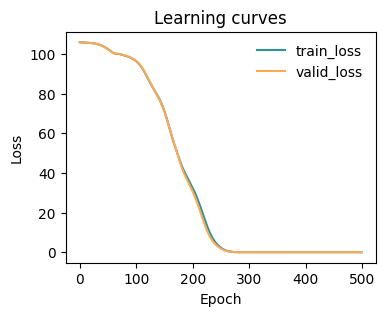

In [5]:
fig, ax = plt.subplots(1,1,figsize=(4,3))
plot_metrics(metrics.metrics,
                  keys=['train_loss', 'valid_loss'],
                  colors=['fessa1', 'fessa5'],
                  yscale='linear',
                  ax = ax)

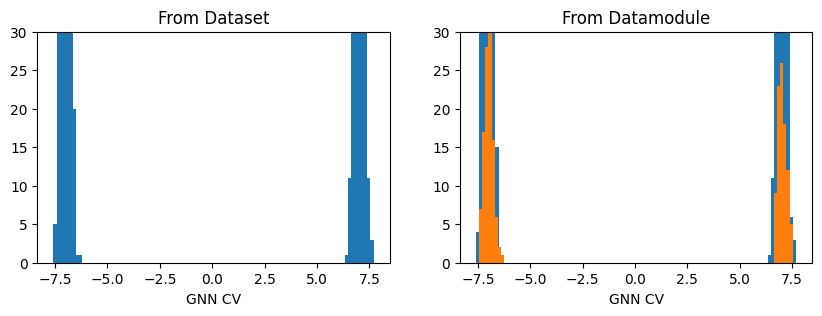

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(10,3))

ax = axs[0]
out_graph = model(dataset.get_graph_inputs())
ax.hist(out_graph.detach().squeeze(), bins=100)
ax.set_title('From Dataset')
ax.set_xlabel('GNN CV')
ax.set_ylim(0,100)

ax = axs[1]
out_graph = model(datamodule.get_graph_inputs("train"))
ax.hist(out_graph.detach().squeeze(), bins=100)
out_graph = model(datamodule.get_graph_inputs("valid"))
ax.hist(out_graph.detach().squeeze(), bins=100)

ax.set_title('From Datamodule')
ax.set_xlabel('GNN CV')
ax.set_ylim(0,100)
plt.show()

In [7]:
traced_model = model.to_torchscript('model.pt', method='trace')

# we can also check the outputs coincide
torch.allclose(model(dataset.get_graph_inputs()), traced_model(dataset.get_graph_inputs()))

/home/etrizio@iit.local/Bin/dev/mlcolvar/mlcolvar/data/datamodule.py:341: UserWarning: Length of split at index 1 is 0. This might result in an empty dataset.
  warnings.warn(


True

In [10]:
from mlcolvar.data.utils import save_dataset_configurations_as_extyz
save_dataset_configurations_as_extyz(dataset, 'test.xyz')